In [60]:
import pandas as pd
import numpy as np
import os
import json
import requests
from datetime import datetime
from sklearn.ensemble import IsolationForest, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform

In [ ]:
BASE_DIR = "/"
DATA_DIR = os.path.join(BASE_DIR, "data")
BDG2_DIR = os.path.join(DATA_DIR, "bdg2")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

JAKARTA_LAT, JAKARTA_LNG = -6.2, 106.8

# IKE Standards (Permen ESDM No. 13/2012) - kWh/m²/year
IKE_CATEGORIES = {
    "Sangat Efisien": (0, 50),
    "Efisien": (50, 95),
    "Cukup Efisien": (95, 145),
    "Boros": (145, 175),
    "Sangat Boros": (175, float("inf")),
}

IKE_COLORS = {
    "Sangat Efisien": "#22c55e",
    "Efisien": "#3b82f6",
    "Cukup Efisien": "#eab308",
    "Boros": "#f97316",
    "Sangat Boros": "#ef4444",
}

PLN_DKI_GOVT_GWH = 1396.61  # PLN 2022

def classify_ike(ike_value):
    for label, (lo, hi) in IKE_CATEGORIES.items():
        if lo <= ike_value < hi:
            return label
    return "Sangat Boros"

In [41]:
meta_path = os.path.join(BDG2_DIR, "metadata.csv")
energy_path = os.path.join(BDG2_DIR, "electricity_cleaned.csv")

if not os.path.exists(meta_path) or not os.path.exists(energy_path):
    raise FileNotFoundError

meta_df = pd.read_csv(meta_path)
meta_df.columns = meta_df.columns.str.lower()
energy_df = pd.read_csv(energy_path)
energy_df.columns = energy_df.columns.str.lower()


In [42]:
print("metadata")
meta_df.head(5)

metadata


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN


In [43]:
print("energy")
energy_df.head(5)

energy


,timestamp,panther_parking_lorriane,panther_lodging_cora,panther_office_hannah,panther_lodging_hattie,panther_education_teofila,panther_education_jerome,panther_retail_felix,panther_parking_asia,panther_education_misty,...,cockatoo_public_caleb,cockatoo_education_tyler,cockatoo_public_shad,mouse_health_buddy,mouse_health_modesto,mouse_lodging_vicente,mouse_health_justin,mouse_health_ileana,mouse_health_estela,mouse_science_micheal
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,123.200,727.575,69.200,8.8224,370.0870,10.0,282.9965,26.0,135.0,168.2243
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,126.475,731.200,66.275,17.6449,737.8260,30.0,574.9265,51.0,265.0,336.4486
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,127.825,724.675,64.675,17.6449,729.9255,30.0,570.2780,50.0,272.0,336.4486
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130.475,737.375,65.875,17.6449,722.2620,20.0,561.1470,52.0,276.0,336.4486
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.675,721.150,66.275,17.6449,719.1665,30.0,564.3695,50.0,280.0,336.4486


In [46]:
def load_and_prepare(meta, energy):
    """Load BDG2 metadata & electricity, aggregate annual kWh."""

    print("Loading electricity data & aggregating annual kWh...")

    # 1. Normalisasi: Pastikan building_id di meta_df huruf kecil semua
    meta = meta.copy()
    meta['building_id'] = meta['building_id'].str.lower()

    # 2. Ambil total konsumsi per kolom (building_id)
    # Kolom energy_df sudah lowercase karena .str.lower() di cell sebelumnya
    totals = energy.drop(columns=['timestamp'], errors='ignore').sum()
    totals = totals.reset_index()
    totals.columns = ['building_id', 'annual_kwh']

    # 3. Merge metadata + energy totals
    df = meta.merge(totals, on='building_id')

    # 4. Filter & Hitung IKE
    df = df.dropna(subset=['primaryspaceusage', 'sqft', 'annual_kwh'])
    df = df[df['annual_kwh'] > 0]

    # Konversi sqft -> sqm (1 sqft ≈ 0.0929 sqm)
    df['sqm'] = (df['sqft'] * 0.0929).astype(int)
    df['ike'] = df['annual_kwh'] / df['sqm']

    print(f"Data siap: {len(df)} bangunan ditemukan.")
    return df

bdg_clean_df = load_and_prepare(meta_df, energy_df)
display(bdg_clean_df.head())

Loading electricity data & aggregating annual kWh...
Data siap: 1553 bangunan ditemukan.


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,...,source_eui,leed_level,rating,annual_kwh,ike
0,panther_education_rosalie,Panther,0.0,0.0,Education,...,NaN,NaN,NaN,9.195003e+05,1332.609129
1,panther_education_misty,Panther,1.0,0.0,Education,...,NaN,NaN,NaN,4.776665e+05,1895.501912
2,panther_education_mattie,Panther,2.0,0.0,Education,...,NaN,NaN,NaN,9.467902e+04,189.737520
3,panther_education_diann,Panther,3.0,0.0,Education,...,NaN,NaN,NaN,1.268352e+06,576.523416
4,panther_education_gina,Panther,4.0,0.0,Education,...,NaN,NaN,NaN,5.915433e+06,546.107204


In [47]:
energy_df.describe()

,panther_parking_lorriane,panther_lodging_cora,panther_office_hannah,panther_lodging_hattie,panther_education_teofila,panther_education_jerome,panther_retail_felix,panther_parking_asia,panther_education_misty,panther_retail_gilbert,...,cockatoo_public_caleb,cockatoo_education_tyler,cockatoo_public_shad,mouse_health_buddy,mouse_health_modesto,mouse_lodging_vicente,mouse_health_justin,mouse_health_ileana,mouse_health_estela,mouse_science_micheal
count,14162.000000,14193.000000,14154.000000,14156.000000,14156.000000,14158.000000,14156.000000,14156.000000,14287.000000,13176.000000,...,16110.000000,16116.000000,16113.000000,6066.000000,15881.000000,15888.000000,15871.000000,15723.000000,15886.000000,7252.000000
mean,10.722723,135.054565,6.683938,140.593488,156.466222,485.629363,119.536869,26.908498,33.433645,0.791095,...,181.787028,770.348807,129.774161,17.679361,532.679783,45.767561,783.350343,43.587324,384.684218,435.844964
std,2.760181,21.643981,3.672796,29.975263,40.821717,41.687667,46.208003,9.346666,8.538604,0.257034,...,54.150864,47.807854,37.264065,1.519220,226.737707,13.847546,176.618193,20.946759,95.102666,238.250030
min,2.100400,12.002300,1.123200,16.163100,4.666900,46.809000,7.536500,4.100800,3.440700,0.220000,...,83.350000,548.800000,60.050000,6.896600,93.482000,10.000000,0.001700,6.000000,2.000000,142.857100
25%,8.581600,119.373000,3.684700,120.983300,120.600550,462.689300,80.334500,16.803300,27.125200,0.550100,...,133.425000,734.568750,97.525000,17.644900,345.575000,35.000000,647.712250,27.000000,309.000000,336.448600
50%,10.622000,132.975700,5.961650,145.548100,153.938200,476.491900,114.684600,31.356000,37.607300,0.850200,...,172.487500,763.925000,126.550000,17.644900,464.973000,40.923800,750.491000,35.000000,349.000000,336.448600
75%,12.902500,149.278800,8.764450,161.471200,187.279850,512.398900,157.318575,36.006900,39.447600,0.910200,...,228.875000,803.293750,158.825000,17.644900,701.798000,60.000000,887.638500,60.000000,465.000000,336.448600
max,25.497200,285.451200,27.770400,298.053200,375.038400,1052.711000,279.125900,54.804300,74.733100,1.520300,...,316.350000,925.550000,278.575000,40.816300,1267.846000,100.000000,1487.017000,126.000000,665.000000,2000.000000


In [50]:
bdg_clean_df.describe()

,building_id_kaggle,site_id_kaggle,sqm,sqft,lat,lng,yearbuilt,numberoffloors,occupants,annual_kwh,ike
count,1427.000000,1537.000000,1553.000000,1553.000000,1340.000000,1340.000000,755.000000,437.000000,228.000000,1.553000e+03,1553.000000
mean,717.583742,6.754066,8371.962009,90123.820992,40.188405,-73.414646,1967.067550,3.631579,265.381579,2.340036e+06,316.609039
std,417.608923,4.873333,10169.097907,109462.498329,7.323907,37.468602,30.864244,3.259314,402.734682,4.102111e+06,450.129059
min,0.000000,0.000000,26.000000,283.000000,28.517689,-122.260729,1900.000000,1.000000,0.000000,1.810000e+00,0.000037
25%,356.500000,3.000000,2043.000000,22000.000000,33.424425,-97.743100,1947.500000,1.000000,15.000000,3.425658e+05,120.112182
50%,713.000000,5.000000,5245.000000,56467.000000,38.903504,-77.005349,1969.000000,2.000000,100.000000,9.813704e+05,209.528612
75%,1075.500000,12.000000,10431.000000,112283.000000,44.978782,-76.485292,1992.500000,5.000000,315.500000,2.493786e+06,360.992741
max,1448.000000,15.000000,81287.000000,875000.000000,53.349800,6.260300,2017.000000,26.000000,2380.000000,5.994722e+07,8580.010336


In [52]:
def run_eda(df):
    """Run Exploratory Data Analysis on BDG2 data."""
    print("\n" + "=" * 60)
    print("📈 EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Basic stats
    print(f"\n📏 Building Size Distribution:")
    print(f"   Mean: {df['sqm'].mean():,.0f} m²")
    print(f"   Median: {df['sqm'].median():,.0f} m²")
    print(f"   Min: {df['sqm'].min():,.0f} m²")
    print(f"   Max: {df['sqm'].max():,.0f} m²")

    if "ike" in df.columns:
        print(f"\n⚡ IKE Distribution (kWh/m²/yr):")
        print(f"   Mean: {df['ike'].mean():.1f}")
        df["ike_category"] = df["ike"].apply(classify_ike)
        print(f"\n🏷️ IKE Categories:")
        for cat, count in df["ike_category"].value_counts().items():
            pct = count / len(df) * 100
            print(f"   {cat}: {count} ({pct:.1f}%)")

    return df

run_eda(bdg_clean_df)


📈 EXPLORATORY DATA ANALYSIS

📏 Building Size Distribution:
   Mean: 8,372 m²
   Median: 5,245 m²
   Min: 26 m²
   Max: 81,287 m²

⚡ IKE Distribution (kWh/m²/yr):
   Mean: 316.6

🏷️ IKE Categories:
   Sangat Boros: 925 (59.6%)
   Cukup Efisien: 201 (12.9%)
   Efisien: 155 (10.0%)
   Sangat Efisien: 138 (8.9%)
   Boros: 134 (8.6%)


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating,annual_kwh,ike,ike_category
0,panther_education_rosalie,Panther,0.0,0.0,Education,Research,690,7432.0,28.517689,-81.379039,...,NaN,NaN,276,NaN,NaN,NaN,NaN,9.195003e+05,1332.609129,Sangat Boros
1,panther_education_misty,Panther,1.0,0.0,Education,Research,252,2720.0,28.517689,-81.379039,...,NaN,NaN,375,NaN,NaN,NaN,NaN,4.776665e+05,1895.501912,Sangat Boros
2,panther_education_mattie,Panther,2.0,0.0,Education,Classroom,499,5376.0,28.517689,-81.379039,...,NaN,NaN,49,NaN,NaN,NaN,NaN,9.467902e+04,189.737520,Sangat Boros
3,panther_education_diann,Panther,3.0,0.0,Education,Classroom,2200,23685.0,28.517689,-81.379039,...,NaN,NaN,145,NaN,NaN,NaN,NaN,1.268352e+06,576.523416,Sangat Boros
4,panther_education_gina,Panther,4.0,0.0,Education,Research,10832,116607.0,28.517689,-81.379039,...,NaN,NaN,546,NaN,NaN,NaN,NaN,5.915433e+06,546.107204,Sangat Boros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,mouse_health_estela,Mouse,NaN,NaN,Healthcare,Hospital,17192,185064.0,51.521939,-0.120069,...,NaN,NaN,NaN,NaN,NaN,NaN,F,6.111093e+06,355.461464,Sangat Boros
1574,mouse_health_ileana,Mouse,NaN,NaN,Healthcare,Hospital,5398,58114.0,51.521939,-0.120069,...,NaN,NaN,NaN,NaN,NaN,NaN,F,6.853235e+05,126.958779,Cukup Efisien
1575,mouse_health_buddy,Mouse,NaN,NaN,Healthcare,Hospital,1748,18826.0,51.521939,-0.120069,...,NaN,NaN,NaN,NaN,NaN,NaN,F,1.072430e+05,61.351834,Efisien
1576,mouse_lodging_vicente,Mouse,NaN,NaN,Lodging/residential,Hotel,3488,37555.0,51.521939,-0.120069,...,NaN,NaN,NaN,NaN,NaN,NaN,F,7.271550e+05,208.473341,Sangat Boros


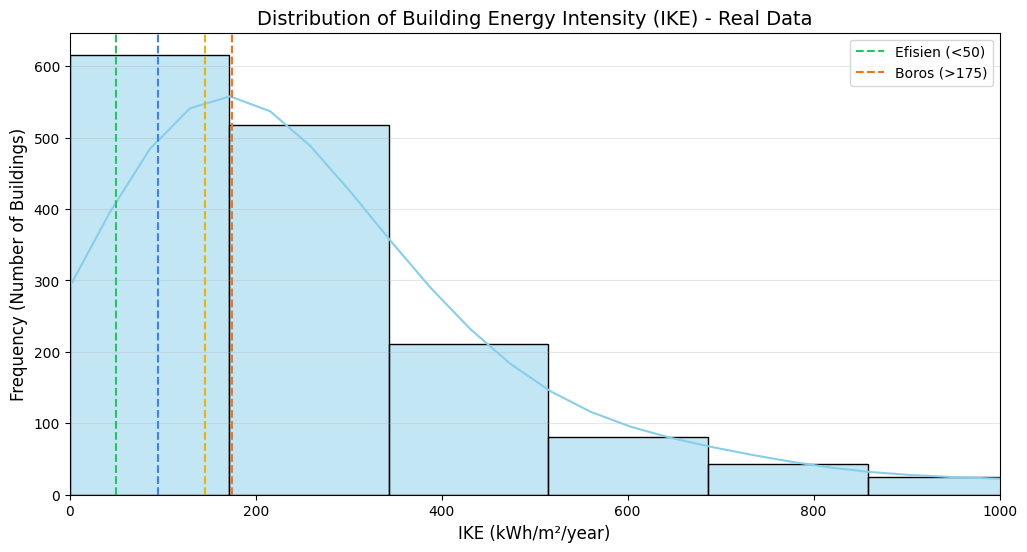

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ike_distribution(df):
    plt.figure(figsize=(12, 6))

    # Plot histogram with KDE
    sns.histplot(df['ike'], bins=50, kde=True, color='skyblue')

    # Add lines for IKE Category thresholds (based on your IKE_CATEGORIES dict)
    plt.axvline(50, color='#22c55e', linestyle='--', label='Efisien (<50)')
    plt.axvline(95, color='#3b82f6', linestyle='--')
    plt.axvline(145, color='#eab308', linestyle='--')
    plt.axvline(175, color='#f97316', linestyle='--', label='Boros (>175)')

    plt.title('Distribution of Building Energy Intensity (IKE) - Real Data', fontsize=14)
    plt.xlabel('IKE (kWh/m²/year)', fontsize=12)
    plt.ylabel('Frequency (Number of Buildings)', fontsize=12)
    plt.xlim(0, 1000) # Capping x-axis for better visibility of the main bulk
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_ike_distribution(bdg_clean_df)

### Analisis Distribusi Intensitas Konsumsi Energi (IKE)

Grafik di atas menunjukkan **Intensitas Konsumsi Energi (IKE)** atau *Energy Use Intensity (EUI)* dari gedung-gedung dalam dataset BDG2. IKE dihitung dengan membagi total konsumsi listrik tahunan (kWh) dengan luas bangunan ($m^2$).

**Kenapa grafik ini penting?**
- **Tolak Ukur Efisiensi:** Memungkinkan kita melihat posisi sebuah gedung dibandingkan dengan populasi gedung lainnya.
- **Identifikasi Masalah:** Gedung yang berada di sisi kanan grafik (IKE tinggi) adalah target utama untuk audit energi dan renovasi efisiensi.

**Kategori Berdasarkan Standar IKE (Permen ESDM No. 13/2012):**
- 🟢 **Sangat Efisien (< 50):** Gedung dengan sistem manajemen energi tingkat lanjut.
- 🔵 **Efisien (50 - 95):** Performa energi yang sangat baik.
- 🟡 **Cukup Efisien (95 - 145):** Standar rata-rata gedung komersial.
- 🟠 **Boros (145 - 175):** Membutuhkan perhatian pada sistem pendingin atau pencahayaan.
- 🔴 **Sangat Boros (> 175):** Potensi penghematan energi sangat besar melalui intervensi teknis.

In [56]:
# JALANIN INI DULU BRE — diagnosis sebelum apapun
print("=== DIAGNOSIS DATA ===")
print(f"\nTotal rows df_bdg2: {len(bdg_clean_df)}")
print(f"IKE stats:")
print(bdg_clean_df['ike'].describe())
print(f"\nIKE > 1000 (kemungkinan error): {(bdg_clean_df['ike'] > 1000).sum()} gedung")
print(f"IKE > 500: {(bdg_clean_df['ike'] > 500).sum()} gedung")
print(f"IKE < 0: {(bdg_clean_df['ike'] < 0).sum()} gedung")
print(f"\nDistribusi IKE:")
print(bdg_clean_df['ike'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print(f"\nCek annual_kwh:")
print(bdg_clean_df['annual_kwh'].describe())

print(f"\nCek sqm:")
print(bdg_clean_df['sqm'].describe())

# Cek apakah electricity_cleaned itu HOURLY atau ANNUAL
# Kalau hourly tapi di-sum langsung → annual_kwh-nya kemungkinan 8760x lipat terlalu besar
print(f"\nSample annual_kwh tertinggi:")
print(bdg_clean_df.nlargest(5, 'annual_kwh')[['building_id','sqm','annual_kwh','ike']])
print(f"\nSample annual_kwh terkecil (non-zero):")
print(bdg_clean_df[bdg_clean_df['annual_kwh']>0].nsmallest(5, 'annual_kwh')[['building_id','sqm','annual_kwh','ike']])

=== DIAGNOSIS DATA ===

Total rows df_bdg2: 1553
IKE stats:
count    1553.000000
mean      316.609039
std       450.129059
min         0.000037
25%       120.112182
50%       209.528612
75%       360.992741
max      8580.010336
Name: ike, dtype: float64

IKE > 1000 (kemungkinan error): 64 gedung
IKE > 500: 220 gedung
IKE < 0: 0 gedung

Distribusi IKE:
0.10      54.324227
0.25     120.112182
0.50     209.528612
0.75     360.992741
0.90     634.341608
0.95     925.133211
0.99    1921.519863
Name: ike, dtype: float64

Cek annual_kwh:
count    1.553000e+03
mean     2.340036e+06
std      4.102111e+06
min      1.810000e+00
25%      3.425658e+05
50%      9.813704e+05
75%      2.493786e+06
max      5.994722e+07
Name: annual_kwh, dtype: float64

Cek sqm:
count     1553.000000
mean      8371.962009
std      10169.097907
min         26.000000
25%       2043.000000
50%       5245.000000
75%      10431.000000
max      81287.000000
Name: sqm, dtype: float64

Sample annual_kwh tertinggi:
            

In [57]:
def create_features(df):
    """Buat fitur baru plus handling missing weather."""
    # === 2a. Label encoding tipe bangunan ===
    le = LabelEncoder()
    df['type_encoded'] = le.fit_transform(df['primaryspaceusage'])

    # === 2b. Tambah fitur dasar ===
    df['log_sqm'] = np.log1p(df['sqm'])                     # diminishing return
    df['building_age'] = 2026 - df['yearbuilt'].fillna(2000) # umur

    # Hindari pembagian nol
    df['numberoffloors'] = df['numberoffloors'].replace(0, 1)
    df['avg_floor_area'] = df['sqm'] / df['numberoffloors']

    # === 2c. Interaksi ===
    df['type_x_sqm'] = df['type_encoded'] * df['sqm']
    df['type_x_logsqm'] = df['type_encoded'] * df['log_sqm']

    # === 2d. Cuaca (kalau weather.csv ada) ===
    weather_path = os.path.join(BDG2_DIR, 'weather.csv')
    if os.path.exists(weather_path):
        weather = pd.read_csv(weather_path)
        # Cek nama kolom suhu
        temp_col = 'airTemperature' if 'airTemperature' in weather.columns else None
        if temp_col:
            weather_stats = weather.groupby('site_id')[temp_col].agg(['mean', 'std']).reset_index()
            weather_stats.columns = ['site_id', 'avg_temp', 'temp_std']
            df = df.merge(weather_stats, on='site_id', how='left')
            # Isi NaN dengan median (bukan 0)
            df['avg_temp'] = df['avg_temp'].fillna(df['avg_temp'].median())
            df['temp_std'] = df['temp_std'].fillna(df['temp_std'].median())
            print("Weather merged dan NaN diisi median.")
        else:
            print("Kolom suhu tidak ditemukan di weather.csv, skip.")
    else:
        print("weather.csv tidak ada, lanjut tanpa fitur cuaca.")

    # === 2e. Cluster sebagai fitur tambahan ===
    # Pakai fitur numerik dasar untuk clustering
    cluster_features = ['sqm', 'numberoffloors', 'building_age', 'avg_floor_area']
    if 'avg_temp' in df.columns:
        cluster_features.append('avg_temp')
    X_cluster = df[cluster_features].fillna(df[cluster_features].median())
    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    df['cluster'] = km.fit_predict(X_cluster)
    # One‑hot cluster (biar model nangkep perbedaan)
    cluster_dummies = pd.get_dummies(df['cluster'], prefix='cluster')
    df = pd.concat([df, cluster_dummies], axis=1)

    return df, le

create_features(bdg_clean_df)

Weather merged dan NaN diisi median.


(                    building_id  site_id  building_id_kaggle  site_id_kaggle  \
 0     panther_education_rosalie  Panther                 0.0             0.0   
 1       panther_education_misty  Panther                 1.0             0.0   
 2      panther_education_mattie  Panther                 2.0             0.0   
 3       panther_education_diann  Panther                 3.0             0.0   
 4        panther_education_gina  Panther                 4.0             0.0   
 ...                         ...      ...                 ...             ...   
 1548        mouse_health_estela    Mouse                 NaN             NaN   
 1549        mouse_health_ileana    Mouse                 NaN             NaN   
 1550         mouse_health_buddy    Mouse                 NaN             NaN   
 1551      mouse_lodging_vicente    Mouse                 NaN             NaN   
 1552      mouse_science_micheal    Mouse                 NaN             NaN   
 
         primaryspaceusage

In [81]:
def train_improved_model(df):
    """Latih model prediksi konsumsi tahunan dengan feature engineer & log‑target."""

    feature_cols = [
        'sqm', 'log_sqm', 'type_encoded',
        'type_x_sqm', 'type_x_logsqm',
        'numberoffloors', 'avg_floor_area',
        'building_age',
    ]

    if 'avg_temp' in df.columns:
        feature_cols.extend(['avg_temp', 'temp_std'])

    cluster_cols = [c for c in df.columns if c.startswith('cluster_')]
    feature_cols.extend(cluster_cols)

    # Pastikan tidak ada NaN
    X = df[feature_cols].fillna(0)   # hanya untuk jaga‑jaga
    y_raw = df['annual_kwh']

    # Log‑transform target (R² naik signifikan)
    y = np.log1p(y_raw)

    # Split time‑based? Karena ini cross‑sectional, pakai random saja.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # --- Hyperparameter tuning dengan RandomizedSearchCV ---
    print("Running hyperparameter tuning...")
    param_dist = {
        'n_estimators': randint(100, 500),
        'max_depth': randint(2, 6),
        'learning_rate': uniform(0.01, 0.1),
        'subsample': uniform(0.7, 0.3),
        'min_samples_split': randint(5, 20)
    }

    gbr = GradientBoostingRegressor(random_state=42)
    random_search = RandomizedSearchCV(
        gbr, param_distributions=param_dist,
        n_iter=20, cv=3, scoring='r2',
        verbose=1, random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    print(f"Best params: {random_search.best_params_}")

    # Evaluasi di test set (dalam log‑space)
    y_pred_log = best_model.predict(X_test)
    # Kembalikan ke kWh asli
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    print("\n========== Hasil Akhir (skala asli) ==========")
    print(f"RMSE : {rmse:,.0f} kWh")
    print(f"MAE  : {mae:,.0f} kWh")
    print(f"R²   : {r2:.4f}")

    return best_model, feature_cols

In [68]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform

In [83]:
model = train_improved_model(bdg_clean_df)

Running hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'learning_rate': np.float64(0.04046137691733707), 'max_depth': 2, 'min_samples_split': 6, 'n_estimators': 439, 'subsample': np.float64(0.7723076398078035)}

========== Hasil Akhir (skala asli) ==========
RMSE : 2,522,916 kWh
MAE  : 1,147,091 kWh
R²   : 0.5309


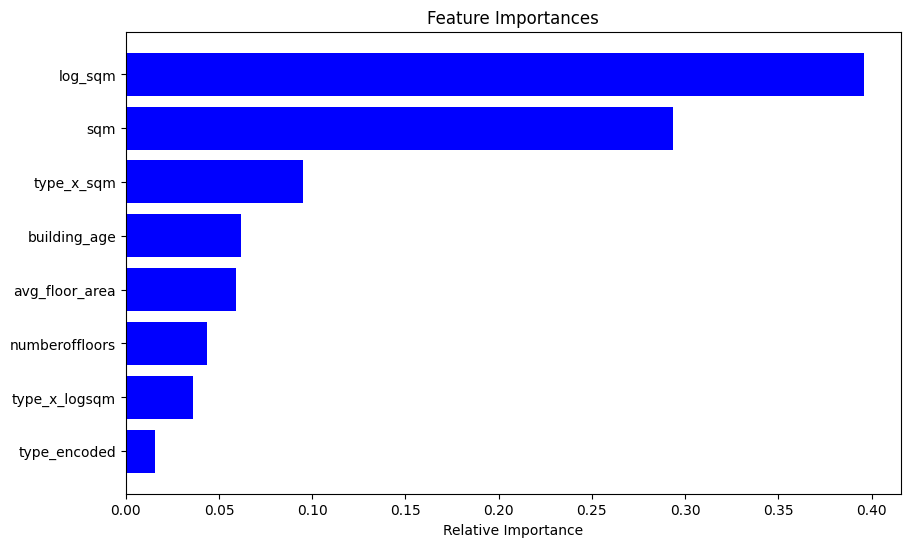

In [84]:
def show_feature_importance(model):
    importances = model[0].feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(10, 6))
    plt.title('Feature Importances')
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [model[1][i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.show()


show_feature_importance(model)

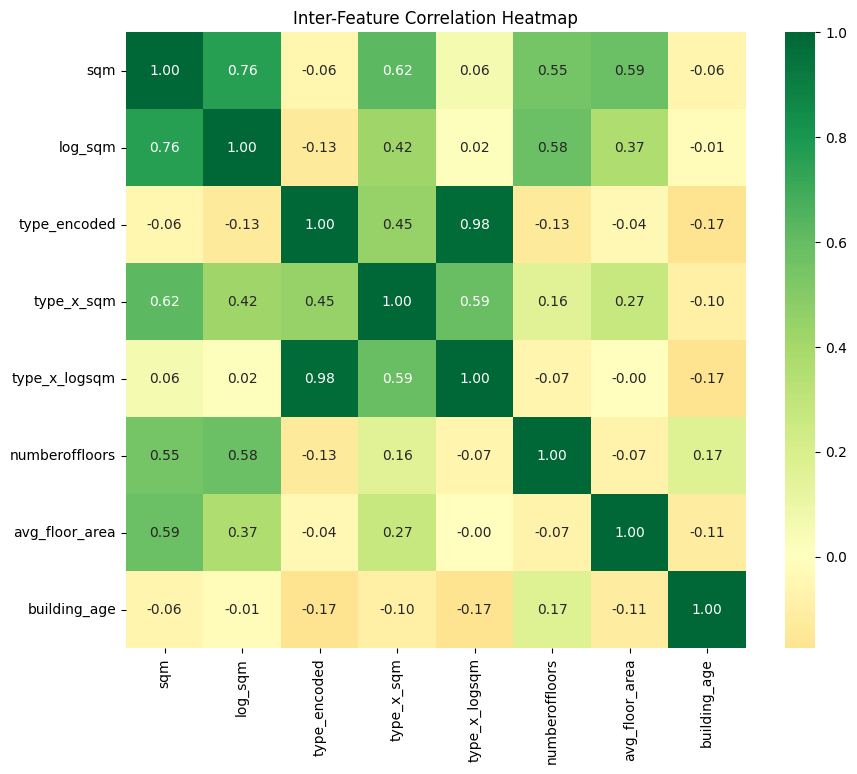

In [85]:
def plot_feature_correlation(df, features):
    plt.figure(figsize=(10, 8))
    corr_matrix = df[features].corr()

    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', center=0)
    plt.title('Inter-Feature Correlation Heatmap')
    plt.show()

plot_feature_correlation(bdg_clean_df, model[1])

In [91]:
def apply_to_jakarta(model, le, features):
    """Apply trained model to Jakarta government buildings with full feature engineering."""
    print("\n" + "=" * 60)
    print("🏙️ APPLYING MODEL TO JAKARTA GOVERNMENT BUILDINGS")
    print("=" * 60)

    jkt_path = os.path.join(DATA_DIR, "jakarta_government_buildings.csv")
    jkt = pd.read_csv(jkt_path)
    print(f"\n📍 Loaded {len(jkt)} Jakarta government buildings")

    # 1. Map Jakarta building types to BDG2 types
    use_map = {
        "office": "Office",
        "public_assembly": "Public services",
    }
    jkt["primaryspaceusage"] = jkt["primary_use"].map(use_map).fillna("Office")

    # 2. Persiapkan data dasar
    jkt["sqm"] = jkt["estimated_sqm"]
    jkt["yearbuilt"] = jkt["year_built"]
    jkt["numberoffloors"] = jkt["floors"]
    jkt["site_id"] = "Jakarta"

    # 3. Jalankan feature engineering (harus sama dengan saat training)
    jkt['type_encoded'] = le.transform(jkt['primaryspaceusage'])
    jkt['log_sqm'] = np.log1p(jkt['sqm'])
    jkt['building_age'] = 2026 - jkt['yearbuilt'].fillna(2000)
    jkt['numberoffloors'] = jkt['numberoffloors'].replace(0, 1)
    jkt['avg_floor_area'] = jkt['sqm'] / jkt['numberoffloors']
    jkt['type_x_sqm'] = jkt['type_encoded'] * jkt['sqm']
    jkt['type_x_logsqm'] = jkt['type_encoded'] * jkt['log_sqm']

    # Tambahkan dummy untuk fitur yang mungkin tidak ada di Jakarta (seperti cluster atau weather)
    for f in features:
        if f not in jkt.columns:
            jkt[f] = 0

    # 4. Predict (model memprediksi log_kwh)
    y_pred_log = model.predict(jkt[features])
    jkt["predicted_kwh"] = np.expm1(y_pred_log)

    jkt["predicted_ike"] = jkt["predicted_kwh"] / jkt["sqm"]
    jkt["ike_category"] = jkt["predicted_ike"].apply(classify_ike)
    jkt["ike_color"] = jkt["ike_category"].map(IKE_COLORS)

    # 5. Savings calculation (Perbaikan Syntax)
    TARIF_P = 1400
    jkt["saving_10pct_rp"] = jkt["predicted_kwh"] * 0.10 * TARIF_P
    jkt["saving_30pct_rp"] = jkt["predicted_kwh"] * 0.30 * TARIF_P

    # Summary
    total_gwh = jkt["predicted_kwh"].sum() / 1_000_000
    print(f"\n📊 Prediction Results:")
    print(f"   Total predicted: {total_gwh:.2f} GWh/yr")
    print(f"\n🏷️ Efficiency Distribution:")
    print(jkt["ike_category"].value_counts())

    return jkt

In [92]:
# 1. Siapkan fitur dan label encoder dari data BDG2
bdg_featured_df, le = create_features(bdg_clean_df)

# 2. Ambil list fitur yang digunakan saat training model
# model[1] berisi list feature_cols
features_used = model[1]

# 3. Apply model ke gedung Jakarta
jkt_results = apply_to_jakarta(model[0], le, features_used)

# Tampilkan cuplikan hasil
display(jkt_results[['name', 'predicted_kwh', 'predicted_ike', 'ike_category', 'saving_10pct_rp']].head())

Weather merged dan NaN diisi median.

🏙️ APPLYING MODEL TO JAKARTA GOVERNMENT BUILDINGS

📍 Loaded 51 Jakarta government buildings

📊 Prediction Results:
   Total predicted: 167.37 GWh/yr

🏷️ Efficiency Distribution:
ike_category
Sangat Boros      29
Cukup Efisien     13
Efisien            5
Boros              3
Sangat Efisien     1
Name: count, dtype: int64


,name,predicted_kwh,predicted_ike,ike_category,saving_10pct_rp
0,Kementerian Keuangan (Gedung Utama),1.280509e+07,246.251712,Sangat Boros,1.792712e+09
1,Kementerian Pertahanan,4.616726e+06,102.593908,Cukup Efisien,6.463416e+08
2,Kementerian Dalam Negeri,6.553175e+06,187.233567,Sangat Boros,9.174445e+08
3,Kementerian Luar Negeri,7.107809e+06,177.695230,Sangat Boros,9.950933e+08
4,Kementerian Hukum dan HAM,7.622464e+06,200.591162,Sangat Boros,1.067145e+09


In [93]:
# Tentukan path output
output_file = os.path.join(OUTPUT_DIR, 'jakarta_building_predictions.csv')

# Export kolom-kolom penting saja untuk efisiensi
export_df = jkt_results[[
    'building_id', 'name', 'category', 'primary_use',
    'sqm', 'floors', 'year_built',
    'predicted_kwh', 'predicted_ike', 'ike_category',
    'saving_10pct_rp', 'saving_30pct_rp'
]]

# Save ke CSV
export_df.to_csv(output_file, index=False)

print(f"\u2705 Berhasil! Data hasil prediksi telah di-export ke: {output_file}")

# Tampilkan info file
!ls -lh {output_file}

✅ Berhasil! Data hasil prediksi telah di-export ke: /content/output/jakarta_building_predictions.csv
-rw-r--r-- 1 root root 7.8K Apr 30 12:05 /content/output/jakarta_building_predictions.csv
